# 01. 探索的データ分析 (EDA)

## Recruit Restaurant Visitor Forecasting

**目的**: データの全体像を把握し、予測に有用なパターンを発見する

### 分析内容
1. データ読み込みと概要
2. 目的変数（来客数）の分布
3. 時系列パターン（曜日・月・年）
4. 店舗属性の分析（ジャンル・エリア）
5. 祝日の影響
6. 予約データの分析
7. 地理的分布
8. EDAまとめ

---
## 1. セットアップとデータ読み込み

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['font.family'] = 'MS Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 12
pd.set_option('display.max_columns', 50)

INPUT_DIR = Path('../input')

# 全データ読み込み
air_visit = pd.read_csv(INPUT_DIR / 'air_visit_data.csv', parse_dates=['visit_date'])
air_reserve = pd.read_csv(INPUT_DIR / 'air_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
air_store = pd.read_csv(INPUT_DIR / 'air_store_info.csv')
hpg_reserve = pd.read_csv(INPUT_DIR / 'hpg_reserve.csv', parse_dates=['visit_datetime', 'reserve_datetime'])
hpg_store = pd.read_csv(INPUT_DIR / 'hpg_store_info.csv')
store_relation = pd.read_csv(INPUT_DIR / 'store_id_relation.csv')
date_info = pd.read_csv(INPUT_DIR / 'date_info.csv', parse_dates=['calendar_date'])
submission = pd.read_csv(INPUT_DIR / 'sample_submission.csv')

print('=== データサイズ ===')
for name, df in [('air_visit_data', air_visit), ('air_reserve', air_reserve),
                  ('air_store_info', air_store), ('hpg_reserve', hpg_reserve),
                  ('hpg_store_info', hpg_store), ('store_id_relation', store_relation),
                  ('date_info', date_info), ('sample_submission', submission)]:
    print(f'  {name:25s}: {df.shape[0]:>10,} 行 × {df.shape[1]:>2} 列')

=== データサイズ ===
  air_visit_data           :    252,108 行 ×  3 列
  air_reserve              :     92,378 行 ×  4 列
  air_store_info           :        829 行 ×  5 列
  hpg_reserve              :  2,000,320 行 ×  4 列
  hpg_store_info           :      4,690 行 ×  5 列
  store_id_relation        :        150 行 ×  2 列
  date_info                :        517 行 ×  3 列
  sample_submission        :     32,019 行 ×  2 列


In [2]:
# 各データの先頭を確認
print('=== air_visit_data (来客履歴) ===')
display(air_visit.head())
print(air_visit.dtypes)

print('\n=== air_store_info (店舗情報) ===')
display(air_store.head())

print('\n=== date_info (日付情報) ===')
display(date_info.head())

=== air_visit_data (来客履歴) ===


,air_store_id,visit_date,visitors
0,air_ba937bf13d40fb24,2016-01-13,25
1,air_ba937bf13d40fb24,2016-01-14,32
2,air_ba937bf13d40fb24,2016-01-15,29
3,air_ba937bf13d40fb24,2016-01-16,22
4,air_ba937bf13d40fb24,2016-01-18,6


air_store_id            object
visit_date      datetime64[ns]
visitors                 int64
dtype: object

=== air_store_info (店舗情報) ===


,air_store_id,air_genre_name,air_area_name,latitude,longitude
0,air_0f0cdeee6c9bf3d7,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
1,air_7cc17a324ae5c7dc,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
2,air_fee8dcf4d619598e,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
3,air_a17f0778617c76e2,Italian/French,Hyōgo-ken Kōbe-shi Kumoidōri,34.695124,135.197853
4,air_83db5aff8f50478e,Italian/French,Tōkyō-to Minato-ku Shibakōen,35.658068,139.751599



=== date_info (日付情報) ===


,calendar_date,day_of_week,holiday_flg
0,2016-01-01,Friday,1
1,2016-01-02,Saturday,1
2,2016-01-03,Sunday,1
3,2016-01-04,Monday,0
4,2016-01-05,Tuesday,0


In [3]:
# 欠損値の確認
print('=== 欠損値 ===')
for name, df in [('air_visit', air_visit), ('air_store', air_store),
                  ('air_reserve', air_reserve), ('date_info', date_info)]:
    missing = df.isnull().sum()
    if missing.any():
        print(f'\n{name}:')
        print(missing[missing > 0])
    else:
        print(f'{name}: 欠損なし')

=== 欠損値 ===
air_visit: 欠損なし
air_store: 欠損なし
air_reserve: 欠損なし
date_info: 欠損なし


---
## 2. 目的変数（来客数）の分布

In [4]:
print('=== 来客数の基本統計 ===')
print(air_visit['visitors'].describe())
print(f'\n店舗数: {air_visit["air_store_id"].nunique()}')
print(f'期間: {air_visit["visit_date"].min().date()} ～ {air_visit["visit_date"].max().date()}')
print(f'歪度: {air_visit["visitors"].skew():.2f}')
print(f'尖度: {air_visit["visitors"].kurtosis():.2f}')

=== 来客数の基本統計 ===
count    252108.000000
mean         20.973761
std          16.757007
min           1.000000
25%           9.000000
50%          17.000000
75%          29.000000
max         877.000000
Name: visitors, dtype: float64

店舗数: 829
期間: 2016-01-01 ～ 2017-04-22
歪度: 3.31
尖度: 74.26


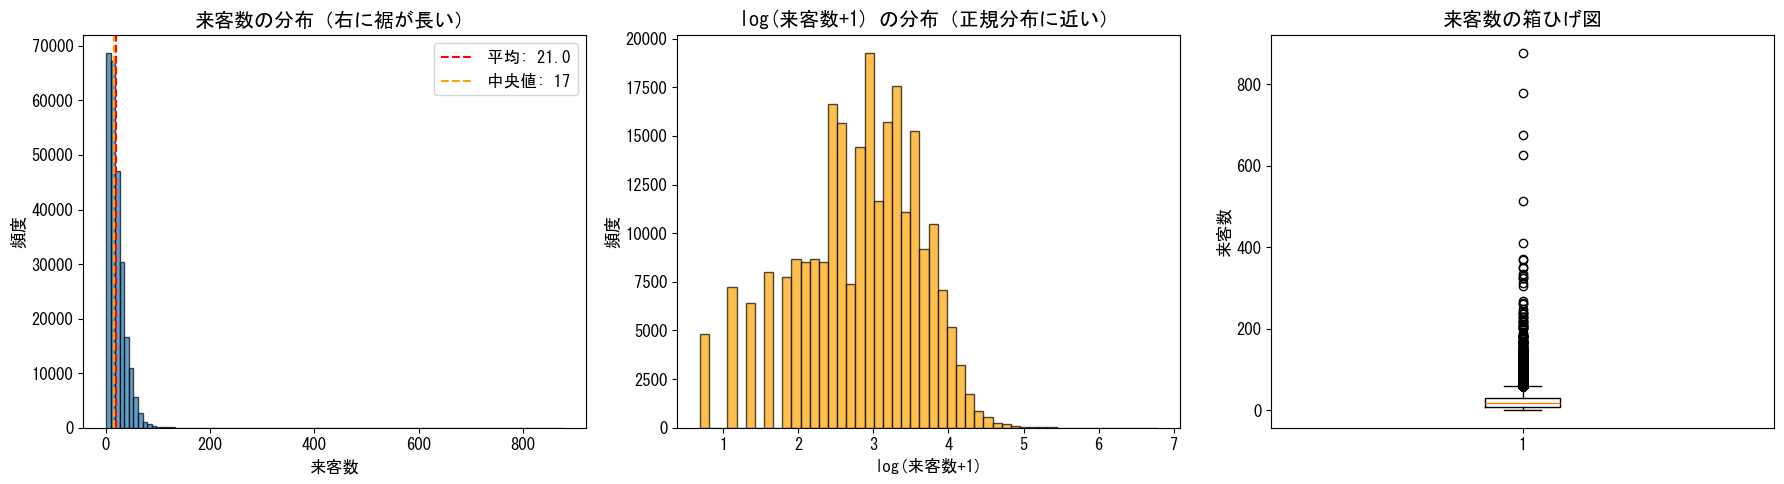

考察:
- 来客数は右に裾の長い分布 → log変換が有効
- RMSLEはlog空間での誤差を評価するため、この性質と整合する
- 外れ値: 5959件が2.4σを超過


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 元の分布
axes[0].hist(air_visit['visitors'], bins=100, edgecolor='black', alpha=0.7)
axes[0].axvline(air_visit['visitors'].mean(), color='red', linestyle='--', label=f'平均: {air_visit["visitors"].mean():.1f}')
axes[0].axvline(air_visit['visitors'].median(), color='orange', linestyle='--', label=f'中央値: {air_visit["visitors"].median():.0f}')
axes[0].set_title('来客数の分布（右に裾が長い）')
axes[0].set_xlabel('来客数')
axes[0].set_ylabel('頻度')
axes[0].legend()

# log変換後
axes[1].hist(np.log1p(air_visit['visitors']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('log(来客数+1) の分布（正規分布に近い）')
axes[1].set_xlabel('log(来客数+1)')
axes[1].set_ylabel('頻度')

# 箱ひげ図
axes[2].boxplot(air_visit['visitors'], vert=True)
axes[2].set_title('来客数の箱ひげ図')
axes[2].set_ylabel('来客数')

plt.tight_layout()
plt.show()

print('考察:')
print('- 来客数は右に裾の長い分布 → log変換が有効')
print('- RMSLEはlog空間での誤差を評価するため、この性質と整合する')
print(f'- 外れ値: {(air_visit["visitors"] > air_visit["visitors"].mean() + 2.4 * air_visit["visitors"].std()).sum()}件が2.4σを超過')

---
## 3. 時系列パターン

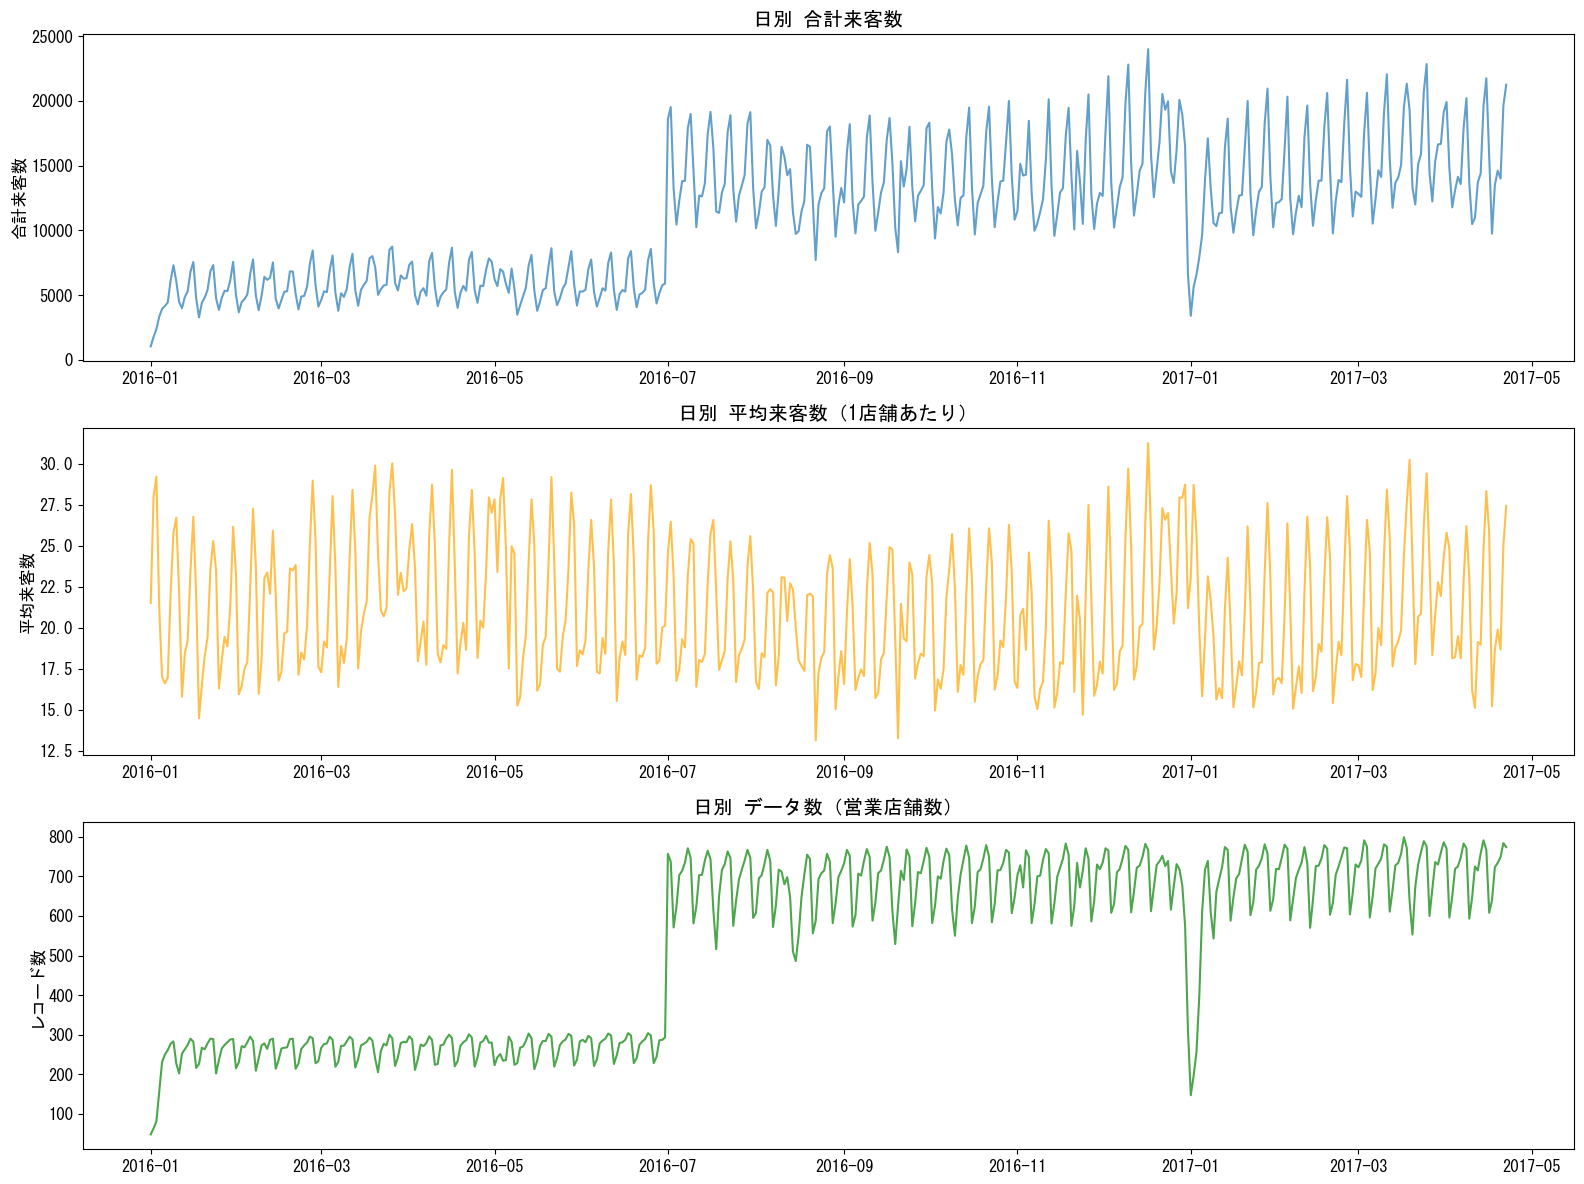

考察:
- 明確な週次パターン（金土にピーク）
- 12月に大きなピーク（忘年会シーズン）
- 営業店舗数は後半に増加傾向


In [6]:
# 日別の来客数推移
daily = air_visit.groupby('visit_date')['visitors'].agg(['sum', 'mean', 'count']).reset_index()

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

axes[0].plot(daily['visit_date'], daily['sum'], alpha=0.7)
axes[0].set_title('日別 合計来客数')
axes[0].set_ylabel('合計来客数')

axes[1].plot(daily['visit_date'], daily['mean'], alpha=0.7, color='orange')
axes[1].set_title('日別 平均来客数（1店舗あたり）')
axes[1].set_ylabel('平均来客数')

axes[2].plot(daily['visit_date'], daily['count'], alpha=0.7, color='green')
axes[2].set_title('日別 データ数（営業店舗数）')
axes[2].set_ylabel('レコード数')

plt.tight_layout()
plt.show()

print('考察:')
print('- 明確な週次パターン（金土にピーク）')
print('- 12月に大きなピーク（忘年会シーズン）')
print('- 営業店舗数は後半に増加傾向')

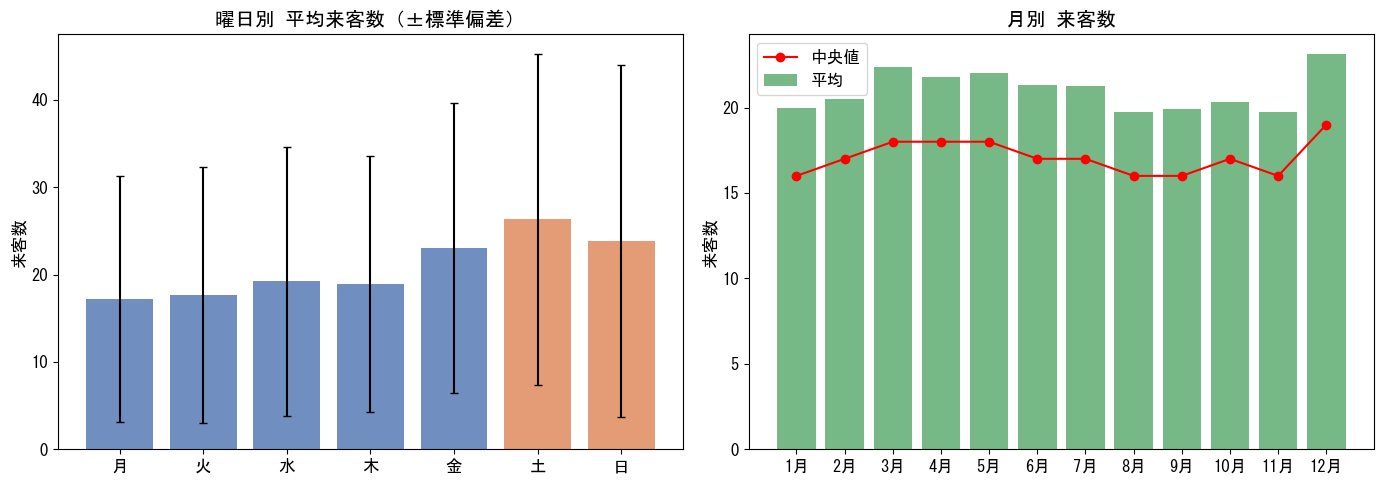

考察:
- 金曜・土曜が最も来客が多い（週末効果）
- 日曜は土曜より少ない（翌日が仕事のため）
- 12月が突出して多い（忘年会シーズン）
- 曜日は非常に強い予測因子 → 特徴量として必須


In [7]:
# 曜日パターン
air_visit['dow'] = air_visit['visit_date'].dt.dayofweek
dow_names = ['月', '火', '水', '木', '金', '土', '日']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dow_stats = air_visit.groupby('dow')['visitors'].agg(['mean', 'median', 'std'])
colors = ['#4C72B0'] * 5 + ['#DD8452'] * 2
axes[0].bar(range(7), dow_stats['mean'], yerr=dow_stats['std'], color=colors, capsize=3, alpha=0.8)
axes[0].set_xticks(range(7))
axes[0].set_xticklabels(dow_names)
axes[0].set_title('曜日別 平均来客数（±標準偏差）')
axes[0].set_ylabel('来客数')

# 月別パターン
air_visit['month'] = air_visit['visit_date'].dt.month
month_stats = air_visit.groupby('month')['visitors'].agg(['mean', 'median'])
axes[1].bar(range(1, 13), month_stats['mean'], color='#55A868', alpha=0.8, label='平均')
axes[1].plot(range(1, 13), month_stats['median'], 'o-', color='red', label='中央値')
axes[1].set_xticks(range(1, 13))
axes[1].set_xticklabels([f'{m}月' for m in range(1, 13)])
axes[1].set_title('月別 来客数')
axes[1].set_ylabel('来客数')
axes[1].legend()

plt.tight_layout()
plt.show()

print('考察:')
print('- 金曜・土曜が最も来客が多い（週末効果）')
print('- 日曜は土曜より少ない（翌日が仕事のため）')
print('- 12月が突出して多い（忘年会シーズン）')
print('- 曜日は非常に強い予測因子 → 特徴量として必須')

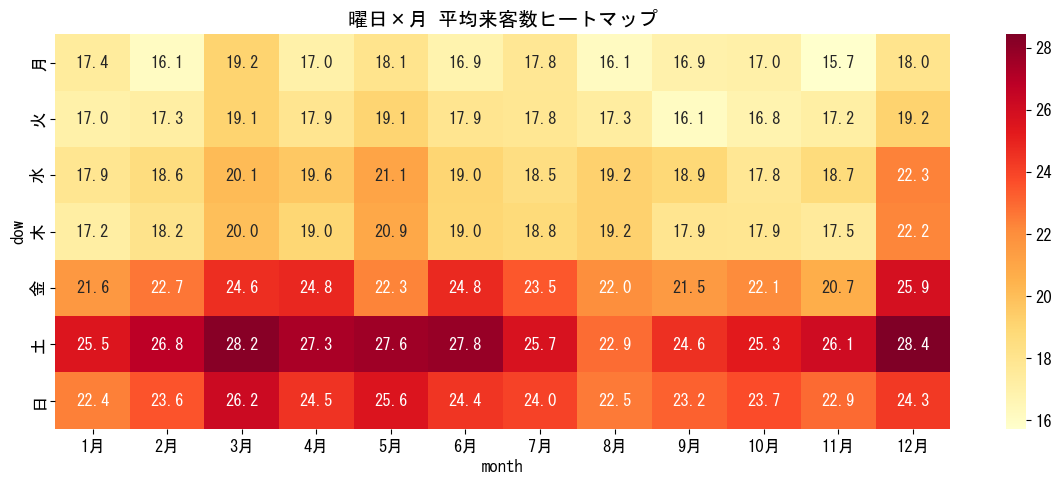

考察:
- 12月の金曜・土曜が最も来客が多い（忘年会のピーク）
- 平日は月による差が比較的小さい


In [8]:
# 曜日×月のヒートマップ
dow_month = air_visit.groupby(['dow', 'month'])['visitors'].mean().unstack()

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(dow_month, annot=True, fmt='.1f', cmap='YlOrRd',
            xticklabels=[f'{m}月' for m in range(1, 13)],
            yticklabels=dow_names, ax=ax)
ax.set_title('曜日×月 平均来客数ヒートマップ')
plt.tight_layout()
plt.show()

print('考察:')
print('- 12月の金曜・土曜が最も来客が多い（忘年会のピーク）')
print('- 平日は月による差が比較的小さい')

---
## 4. 店舗属性の分析

ジャンル数: 14
エリア数: 103


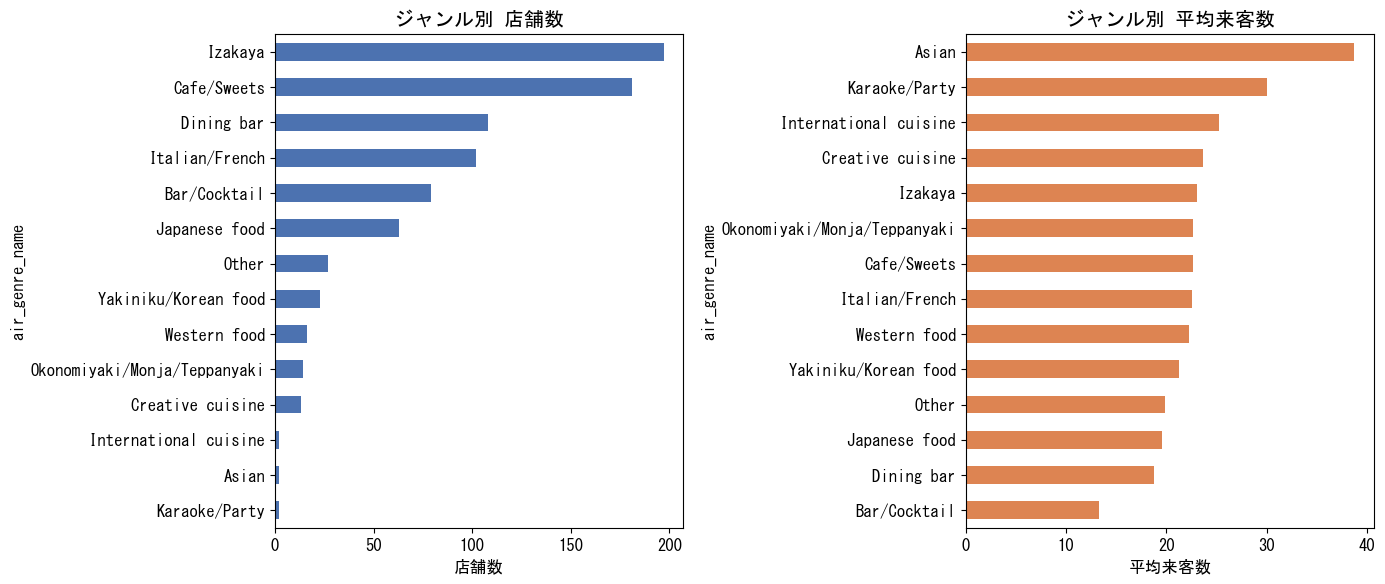

考察:
- 居酒屋(Izakaya)が最多で、来客数も多い
- カラオケ・パーティーは店舗数は少ないが来客数が多い
- ジャンルにより来客規模が大きく異なる → 重要な特徴量


In [9]:
# ジャンル分析
print(f'ジャンル数: {air_store["air_genre_name"].nunique()}')
print(f'エリア数: {air_store["air_area_name"].nunique()}')

merged = air_visit.merge(air_store[['air_store_id', 'air_genre_name', 'air_area_name']], on='air_store_id')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ジャンル別店舗数
genre_count = air_store['air_genre_name'].value_counts()
genre_count.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('ジャンル別 店舗数')
axes[0].set_xlabel('店舗数')
axes[0].invert_yaxis()

# ジャンル別平均来客数
genre_visitors = merged.groupby('air_genre_name')['visitors'].mean().sort_values(ascending=True)
genre_visitors.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('ジャンル別 平均来客数')
axes[1].set_xlabel('平均来客数')

plt.tight_layout()
plt.show()

print('考察:')
print('- 居酒屋(Izakaya)が最多で、来客数も多い')
print('- カラオケ・パーティーは店舗数は少ないが来客数が多い')
print('- ジャンルにより来客規模が大きく異なる → 重要な特徴量')

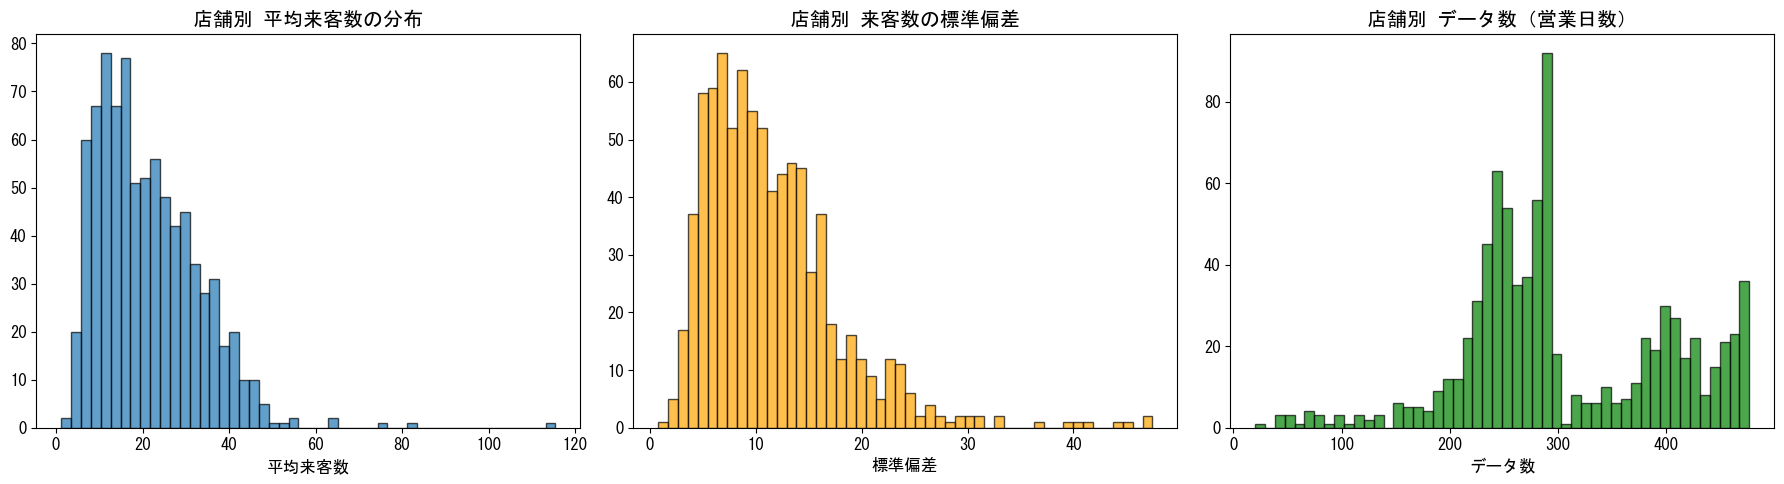

考察:
- 平均来客数が最も多い店舗: 115人
- データ数が少ない店舗（<30日）: 1店舗
- 店舗ごとの来客パターンは大きくばらつく → 店舗別統計量が重要


In [10]:
# 店舗ごとの来客数分布
store_stats = air_visit.groupby('air_store_id')['visitors'].agg(['mean', 'std', 'count'])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(store_stats['mean'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('店舗別 平均来客数の分布')
axes[0].set_xlabel('平均来客数')

axes[1].hist(store_stats['std'], bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('店舗別 来客数の標準偏差')
axes[1].set_xlabel('標準偏差')

axes[2].hist(store_stats['count'], bins=50, edgecolor='black', alpha=0.7, color='green')
axes[2].set_title('店舗別 データ数（営業日数）')
axes[2].set_xlabel('データ数')

plt.tight_layout()
plt.show()

print('考察:')
print(f'- 平均来客数が最も多い店舗: {store_stats["mean"].max():.0f}人')
print(f'- データ数が少ない店舗（<30日）: {(store_stats["count"] < 30).sum()}店舗')
print('- 店舗ごとの来客パターンは大きくばらつく → 店舗別統計量が重要')

---
## 5. 祝日の影響

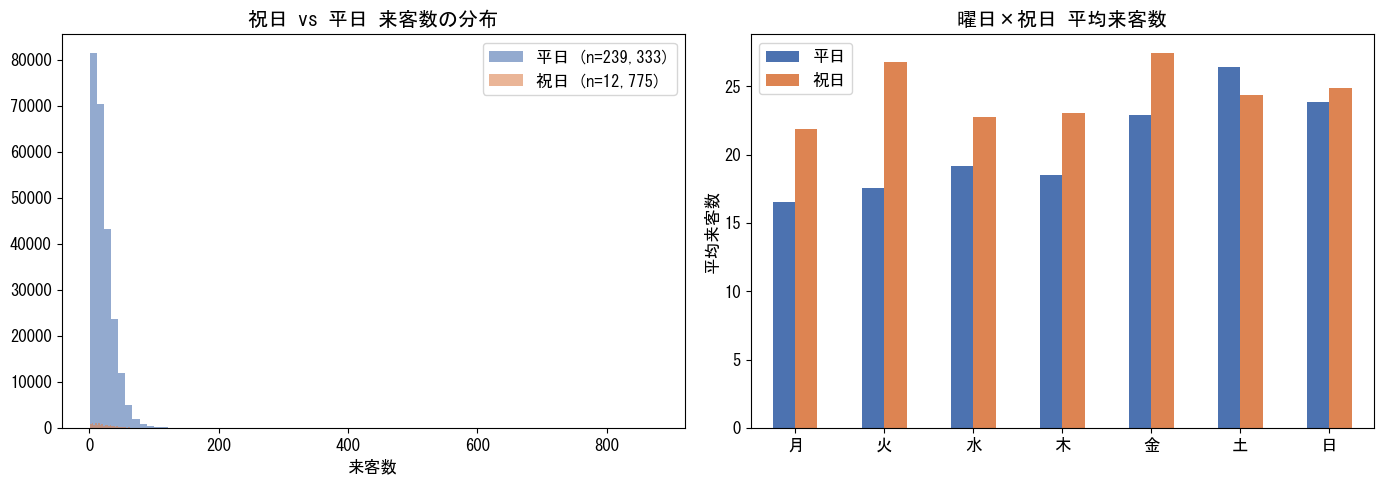

         mean  median
平日  20.828064    17.0
祝日  23.703327    19.0

祝日効果: +13.8%

考察:
- 祝日は来客数が約14%増加
- 祝日フラグは予測に有用だが、祝日の「前日」も重要（飲み会前日効果）


In [11]:
# 祝日 vs 平日
visit_holiday = air_visit.merge(
    date_info.rename(columns={'calendar_date': 'visit_date'}),
    on='visit_date', how='left'
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 祝日フラグ別の分布
for flag, label, color in [(0, '平日', '#4C72B0'), (1, '祝日', '#DD8452')]:
    data = visit_holiday[visit_holiday['holiday_flg'] == flag]['visitors']
    axes[0].hist(data, bins=80, alpha=0.6, label=f'{label} (n={len(data):,})', color=color)
axes[0].set_title('祝日 vs 平日 来客数の分布')
axes[0].set_xlabel('来客数')
axes[0].legend()

# 曜日別に祝日の影響
holiday_dow = visit_holiday.groupby(['dow', 'holiday_flg'])['visitors'].mean().unstack()
holiday_dow.columns = ['平日', '祝日']
holiday_dow.index = dow_names
holiday_dow.plot(kind='bar', ax=axes[1], color=['#4C72B0', '#DD8452'])
axes[1].set_title('曜日×祝日 平均来客数')
axes[1].set_ylabel('平均来客数')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

holiday_stats = visit_holiday.groupby('holiday_flg')['visitors'].agg(['mean', 'median'])
holiday_stats.index = ['平日', '祝日']
print(holiday_stats)
print(f'\n祝日効果: +{(holiday_stats.loc["祝日", "mean"] / holiday_stats.loc["平日", "mean"] - 1) * 100:.1f}%')
print('\n考察:')
print('- 祝日は来客数が約14%増加')
print('- 祝日フラグは予測に有用だが、祝日の「前日」も重要（飲み会前日効果）')

---
## 6. 予約データの分析

In [12]:
# Air予約データの分析
air_reserve['visit_date'] = air_reserve['visit_datetime'].dt.date
air_reserve['reserve_date'] = air_reserve['reserve_datetime'].dt.date
air_reserve['days_before'] = (pd.to_datetime(air_reserve['visit_date']) - pd.to_datetime(air_reserve['reserve_date'])).dt.days

print(f'Air予約: {len(air_reserve):,}件')
print(f'  ユニーク店舗数: {air_reserve["air_store_id"].nunique()}')
print(f'  予約人数 平均: {air_reserve["reserve_visitors"].mean():.1f}人')
print(f'  事前予約日数 平均: {air_reserve["days_before"].mean():.1f}日')

print(f'\nHPG予約: {len(hpg_reserve):,}件')
print(f'  ユニーク店舗数: {hpg_reserve["hpg_store_id"].nunique()}')
print(f'  予約人数 平均: {hpg_reserve["reserve_visitors"].mean():.1f}人')

print(f'\n店舗紐付け: {len(store_relation)}件（HPG→Airの対応）')
print(f'  Airの{air_store.shape[0]}店舗中 {store_relation["air_store_id"].nunique()}店舗がHPGにも登録')

Air予約: 92,378件
  ユニーク店舗数: 314
  予約人数 平均: 4.5人
  事前予約日数 平均: 8.2日

HPG予約: 2,000,320件
  ユニーク店舗数: 13325
  予約人数 平均: 5.1人

店舗紐付け: 150件（HPG→Airの対応）
  Airの829店舗中 150店舗がHPGにも登録


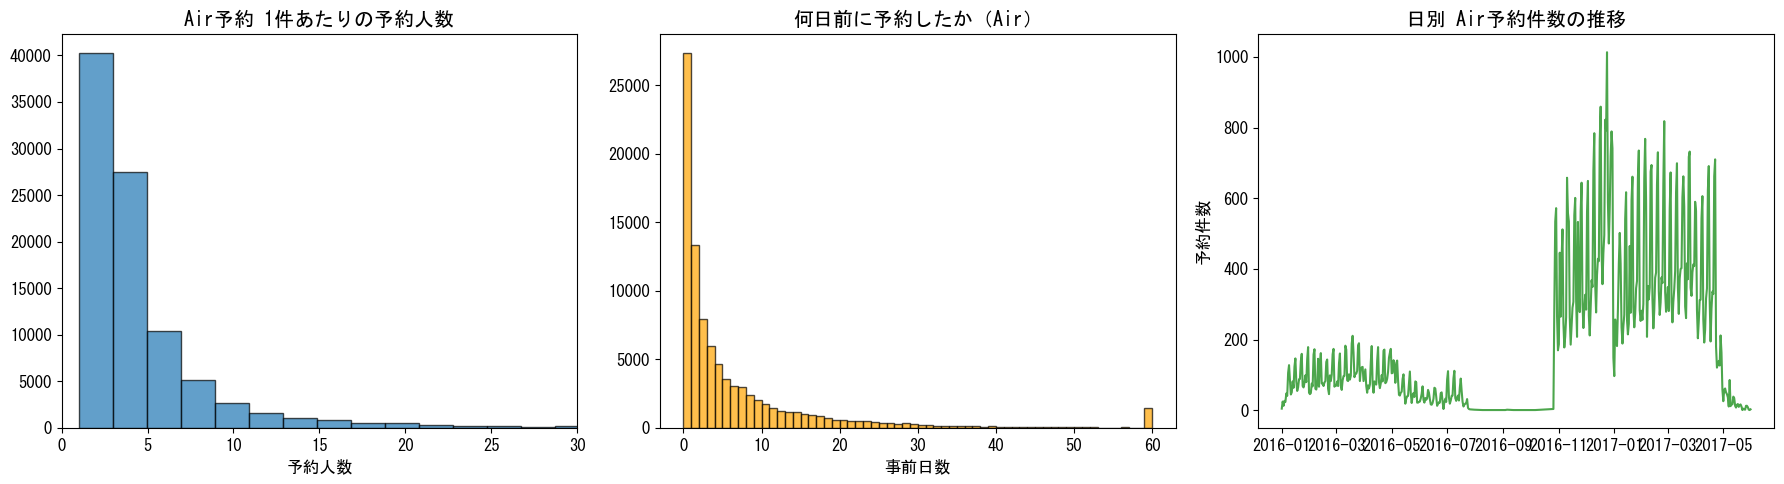

考察:
- 予約は2-4人が大半
- 当日予約が最も多い（直前予約が主流）
- 予約データは来客数の先行指標として有用
- ただしカバー率が低い（全来客のうち予約ありは一部）


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 予約人数の分布
axes[0].hist(air_reserve['reserve_visitors'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Air予約 1件あたりの予約人数')
axes[0].set_xlabel('予約人数')
axes[0].set_xlim(0, 30)

# 事前予約日数
axes[1].hist(air_reserve['days_before'].clip(0, 60), bins=60, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_title('何日前に予約したか（Air）')
axes[1].set_xlabel('事前日数')

# 日別予約件数の推移
air_res_daily = air_reserve.groupby('visit_date').size()
axes[2].plot(pd.to_datetime(air_res_daily.index), air_res_daily.values, alpha=0.7, color='green')
axes[2].set_title('日別 Air予約件数の推移')
axes[2].set_ylabel('予約件数')

plt.tight_layout()
plt.show()

print('考察:')
print('- 予約は2-4人が大半')
print('- 当日予約が最も多い（直前予約が主流）')
print('- 予約データは来客数の先行指標として有用')
print('- ただしカバー率が低い（全来客のうち予約ありは一部）')

---
## 7. 地理的分布

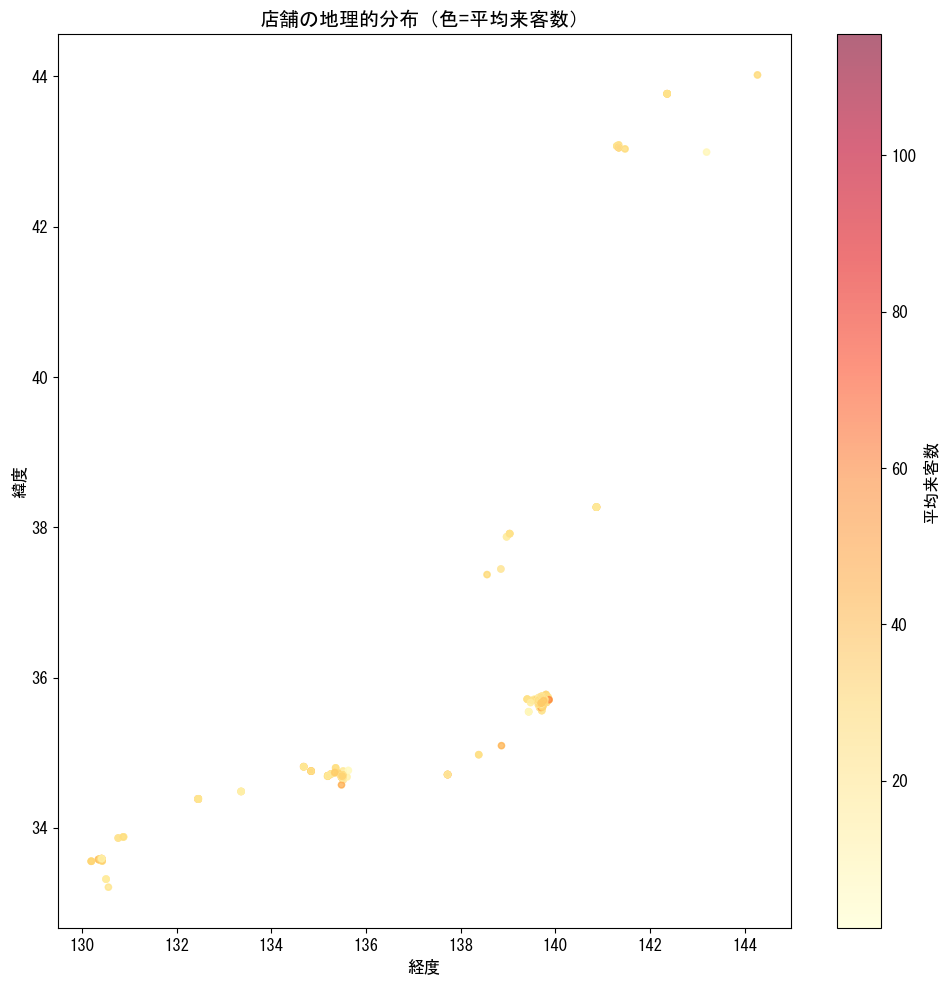

都道府県別 店舗数:
air_area_name
Tōkyō-to         444
Fukuoka-ken      127
Ōsaka-fu          74
Hyōgo-ken         57
Hokkaidō          46
Hiroshima-ken     32
Shizuoka-ken      18
Miyagi-ken        17
Niigata-ken       14
Name: count, dtype: int64


In [14]:
# 店舗の地理的分布
fig, ax = plt.subplots(figsize=(10, 10))

store_with_visitors = air_store.merge(
    air_visit.groupby('air_store_id')['visitors'].mean().reset_index(),
    on='air_store_id'
)

scatter = ax.scatter(
    store_with_visitors['longitude'],
    store_with_visitors['latitude'],
    c=store_with_visitors['visitors'],
    s=20, cmap='YlOrRd', alpha=0.6
)
plt.colorbar(scatter, label='平均来客数')
ax.set_title('店舗の地理的分布（色=平均来客数）')
ax.set_xlabel('経度')
ax.set_ylabel('緯度')

plt.tight_layout()
plt.show()

# エリア別の店舗数上位10
prefecture = air_store['air_area_name'].apply(lambda x: x.split(' ')[0])
print('都道府県別 店舗数:')
print(prefecture.value_counts().head(10))

---
## 8. 提出データの確認

In [15]:
# 提出データ
submission['air_store_id'] = submission['id'].apply(lambda x: x.rsplit('_', 1)[0])
submission['visit_date'] = pd.to_datetime(submission['id'].apply(lambda x: x.rsplit('_', 1)[1]))

print(f'予測対象店舗数: {submission["air_store_id"].nunique()}')
print(f'予測期間: {submission["visit_date"].min().date()} ～ {submission["visit_date"].max().date()}')
print(f'予測レコード数: {len(submission):,}')

train_stores = set(air_visit['air_store_id'].unique())
test_stores = set(submission['air_store_id'].unique())
print(f'\n学習データの店舗: {len(train_stores)}')
print(f'テストデータの店舗: {len(test_stores)}')
print(f'テストのみの店舗: {len(test_stores - train_stores)}')
print(f'学習のみの店舗: {len(train_stores - test_stores)}')

予測対象店舗数: 821
予測期間: 2017-04-23 ～ 2017-05-31
予測レコード数: 32,019

学習データの店舗: 829
テストデータの店舗: 821
テストのみの店舗: 0
学習のみの店舗: 8


---
## 9. EDAまとめ

### 発見した主要パターン

| パターン | 詳細 | 予測への活用 |
|---------|------|-------------|
| 曜日効果 | 金土にピーク、月火が少ない | `dow` 特徴量 |
| 月次効果 | 12月が突出（忘年会） | `month` 特徴量 |
| 祝日効果 | 平日比 +14% | `is_holiday`, `is_before_holiday` |
| ジャンル差 | 居酒屋 > カフェ 等 | `genre` 特徴量 |
| 店舗個性 | 店舗ごとに来客規模が異なる | 店舗別統計量 |
| 予約情報 | 来客の先行指標 | 予約人数集計 |

### 目的変数の性質
- **右裾が長い分布** → log変換が有効
- **RMSLE** = log空間でのRMSE → log変換した目的変数で学習すべき

### データの注意点
- 欠損日（営業していない日）はデータに含まれない
- 外れ値あり（877人の日など）
- 予約データのカバー率は低い → 欠損値の処理が必要
- テスト期間の全店舗は学習データに存在する（新規店舗問題なし）